In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Loading the data


In [26]:
#loading the mnist data
dataset = MNIST(
    root="./data",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

#dataloader
loader = DataLoader(dataset, batch_size=512, shuffle=True)
images, labels = next(iter(loader))

print(images.shape)
print(labels.shape)



torch.Size([512, 1, 28, 28])
torch.Size([512])


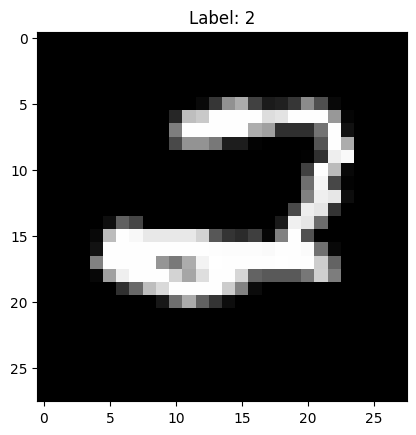

In [27]:
#testing laoded MNIST data
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.show()


Definfing model

In [28]:
class VariationlAutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=128):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )

        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        hidden = self.encoder(x)
        mu = self.mu(hidden)
        logvar = self.logvar(hidden)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

TRAINING OUR DATA!!

In [33]:
model = VariationlAutoEncoder(input_dim=784, latent_dim=8)  # 784 = 28x28 MNIST
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss(reduction='mean') #binary loss for greyscale image reonstruction

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
epochs = 20
for epoch in range(epochs):
    beta = epoch / epochs
    total_loss = 0
    for images, _ in loader:
        images = images.view(-1, 784).to(device)
        recon,mu,logvar = model(images)
        recon_loss = criterion(recon, images)
        KL_divergence = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + 0.1 * KL_divergence / images.size(0)  # Normalize by batch size

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f}")
    print(f"Recon Loss: {loss.item():.4f}, KL Divergence: {KL_divergence.item():.4f}")

Epoch 1/20 | Loss: 0.1313
Recon Loss: 0.1447, KL Divergence: 5.2251
Epoch 2/20 | Loss: 0.1305
Recon Loss: 0.1338, KL Divergence: 5.3339
Epoch 3/20 | Loss: 0.1301
Recon Loss: 0.1319, KL Divergence: 5.4912
Epoch 4/20 | Loss: 0.1296
Recon Loss: 0.1353, KL Divergence: 5.6351
Epoch 5/20 | Loss: 0.1292
Recon Loss: 0.1297, KL Divergence: 5.4678
Epoch 6/20 | Loss: 0.1289
Recon Loss: 0.1375, KL Divergence: 5.4104
Epoch 7/20 | Loss: 0.1285
Recon Loss: 0.1330, KL Divergence: 5.6012
Epoch 8/20 | Loss: 0.1282
Recon Loss: 0.1325, KL Divergence: 5.8378
Epoch 9/20 | Loss: 0.1279
Recon Loss: 0.1312, KL Divergence: 5.6203
Epoch 10/20 | Loss: 0.1277
Recon Loss: 0.1322, KL Divergence: 6.0415
Epoch 11/20 | Loss: 0.1275
Recon Loss: 0.1336, KL Divergence: 5.9126
Epoch 12/20 | Loss: 0.1272
Recon Loss: 0.1336, KL Divergence: 5.8085
Epoch 13/20 | Loss: 0.1269
Recon Loss: 0.1298, KL Divergence: 5.9889
Epoch 14/20 | Loss: 0.1268
Recon Loss: 0.1318, KL Divergence: 6.3149
Epoch 15/20 | Loss: 0.1265
Recon Loss: 0.12

PLotting it 

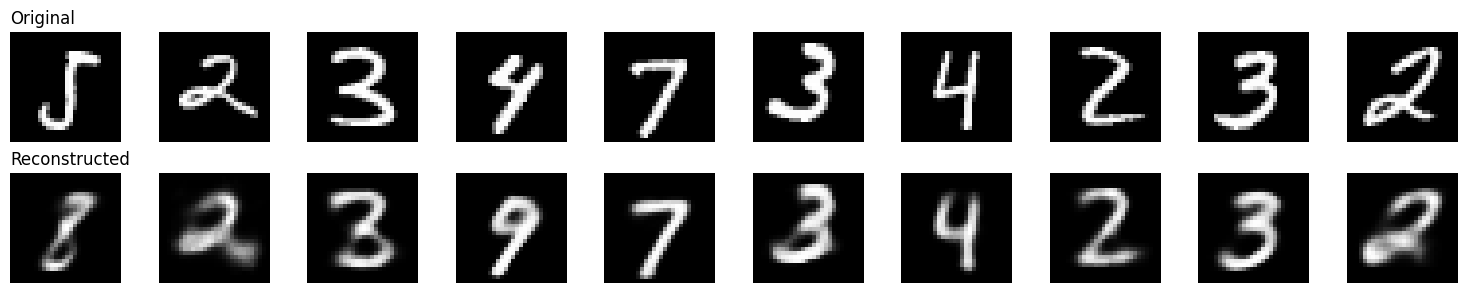

In [39]:
model.eval()
with torch.no_grad():
    images, _ = next(iter(loader))
    images_flat = images.view(-1, 784).to(device)
    recon,mew,logvar = model(images_flat)

    # Reshape back to 28x28 for display
    images_grid = images.view(-1, 28, 28)
    recon_grid = recon.view(-1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(images_grid[i].cpu(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_grid[i].cpu(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title('Original', loc='left')
axes[1, 0].set_title('Reconstructed', loc='left')
plt.tight_layout()
plt.show()

In a VAE, the latent space is learned probabilistically as a continuous distribution. By forcing the data into a structured 'neighborhood' (using KL Divergence and noise), the model ensures that every coordinate in that space represents a meaningful variation of the data. When we provide a random vector via torch.randn, the decoder can 'hallucinate' a realistic image because it has learned the underlying rules of the dataset, rather than just memorizing specific locations.

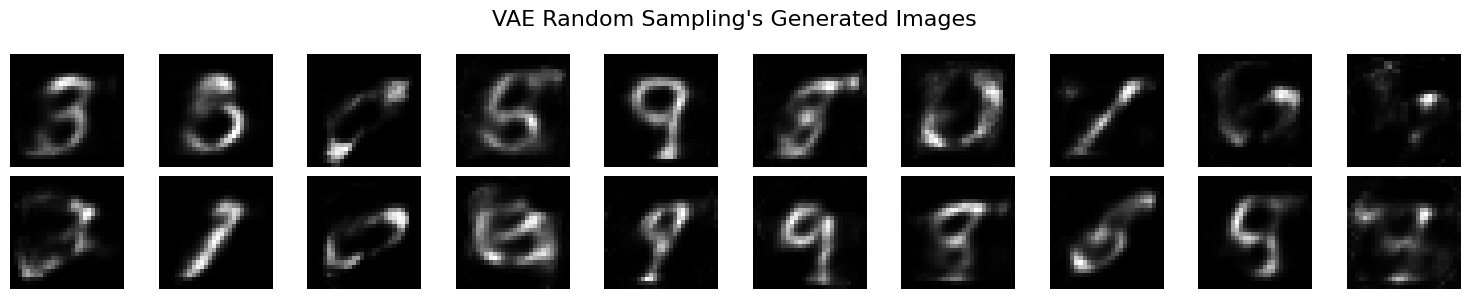

In [40]:
model.eval()
with torch.no_grad():
    latent_dim = 8
    z = torch.randn(20, latent_dim).to(device)
    generated = model.run_decoder(z) if hasattr(model, "run_decoder") else model.decoder(z)

    generated = generated.view(-1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    axes[i//10, i%10].imshow(generated[i].cpu(), cmap="gray")
    axes[i//10, i%10].axis("off")

plt.suptitle("VAE Random Sampling's Generated Images", fontsize=16)
plt.tight_layout()
plt.show()